## Notebook 3: Giải thích mô hình bằng SHAP (Explainable AI - XAI)

---
**Mô tả:**
Mô hình Random Forest tuy có hiệu năng cao nhưng thường được xem là một "Hộp đen" (Black Box) phức tạp. Trong Notebook này, chúng ta sẽ áp dụng các lý thuyết trò chơi hợp tác thông qua phương pháp **SHAP (SHapley Additive exPlanations)** để mở hộp đen mô hình:
1. Phân tích tầm quan trọng toàn cục (Global Explainability) của các đặc trưng thông qua biểu đồ Dot Plot và Bar Plot.
2. Giải thích cục bộ (Local Explainability) cho từng giao dịch đơn lẻ, chỉ rõ lực đẩy tăng/giảm xác suất gian lận bằng biểu đồ Force Plot và Waterfall Plot.
3. Cho phép chỉnh sửa tham số đặc trưng What-If và phân tích sự thay đổi rủi ro giao dịch theo thời gian thực.

---

In [1]:
# Import các thư viện giải thích mô hình (SHAP)
import os
import sys
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

# Khởi tạo cấu hình vẽ đồ thị
plt.rcParams["figure.figsize"] = (10, 6)
shap.initjs() # Kích hoạt Javascript để render đồ thị tương tác

print("[LOG] Đã import thư viện SHAP thành công.")

[LOG] Đã import thư viện SHAP thành công.


In [2]:
# Thiết lập các đường dẫn tương thích Google Colab và Local IDE
IS_COLAB = 'google.colab' in sys.modules or os.path.exists('/content/drive')

if IS_COLAB:
    print("[LOG] Phát hiện môi trường chạy: Google Colab.")
    if not os.path.exists('/content/drive'):
        from google.colab import drive
        drive.mount('/content/drive')

    BASE_DIR = '/content/drive/MyDrive/Dataset'
    PROCESSED_DIR = os.path.join(BASE_DIR, 'data/processed')
    MODELS_DIR = os.path.join(BASE_DIR, 'models')
else:
    print("[LOG] Phát hiện môi trường chạy cục bộ (Local IDE).")
    def find_project_root():
        curr = os.path.abspath(os.getcwd())
        for _ in range(5):
            if os.path.exists(os.path.join(curr, "data")) or os.path.exists(os.path.join(curr, "README.md")):
                return curr
            curr = os.path.dirname(curr)
        return curr

    PROJECT_ROOT = find_project_root()
    PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data/processed')
    MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')

MODEL_FILE = os.path.join(MODELS_DIR, "RandomForest_SMOTE.joblib")
SCALER_AMOUNT_FILE = os.path.join(MODELS_DIR, "scaler_amount.joblib")
SCALER_TIME_FILE = os.path.join(MODELS_DIR, "scaler_time.joblib")

if not os.path.exists(MODEL_FILE):
    raise FileNotFoundError(
        f"[ERROR] Không tìm thấy mô hình tại '{MODEL_FILE}'. Vui lòng chạy Notebook 2 trước."
    )

model_rf = joblib.load(MODEL_FILE)
scaler_amount = joblib.load(SCALER_AMOUNT_FILE)
scaler_time = joblib.load(SCALER_TIME_FILE)

print(f"[LOG] Nạp thành công mô hình RandomForest (SMOTE) và bộ chuẩn hóa Scaler từ '{MODELS_DIR}'.")

[LOG] Phát hiện môi trường chạy: Google Colab.
Mounted at /content/drive
[LOG] Nạp thành công mô hình RandomForest (SMOTE) và bộ chuẩn hóa Scaler từ '/content/drive/MyDrive/Dataset/models'.


In [3]:
# Load sample test data phục vụ phân tích SHAP
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test_scaled.csv"))
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test.csv")).squeeze("columns").astype(int)

# Để tính toán SHAP nhanh chóng, ta chọn lọc ngẫu nhiên một tập mẫu 300 dòng từ tập Test
fraud_samples = X_test[y_test == 1]
normal_samples = X_test[y_test == 0].sample(n=250, random_state=42)

X_sample_shap = pd.concat([fraud_samples, normal_samples]).sample(frac=1.0, random_state=42)
y_sample_shap = y_test.loc[X_sample_shap.index]

print(f"[LOG] Chuẩn bị tập dữ liệu phân tích SHAP thành công với kích thước: {X_sample_shap.shape[0]} dòng từ '{PROCESSED_DIR}'.")
print(f" Trong đó chứa: {y_sample_shap.sum()} giao dịch gian lận thực tế.")

[LOG] Chuẩn bị tập dữ liệu phân tích SHAP thành công với kích thước: 348 dòng từ '/content/drive/MyDrive/Dataset/data/processed'.
 Trong đó chứa: 98 giao dịch gian lận thực tế.


In [4]:
# Khởi tạo SHAP TreeExplainer
print("[LOG] Đang khởi tạo SHAP TreeExplainer cho mô hình Random Forest...")
explainer = shap.TreeExplainer(model_rf)
print("[LOG] Khởi tạo TreeExplainer hoàn tất!")

[LOG] Đang khởi tạo SHAP TreeExplainer cho mô hình Random Forest...
[LOG] Khởi tạo TreeExplainer hoàn tất!


In [5]:
# Tính toán SHAP values trên tập mẫu dữ liệu
print("[LOG] Bắt đầu tính toán giá trị SHAP...")
shap_values_raw = explainer.shap_values(X_sample_shap)

# Thư viện SHAP phiên bản mới có thể trả về mảng trực tiếp cho lớp dương hoặc trả về danh sách dạng [class0, class1]
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
else:
    if len(shap_values_raw.shape) == 3:
        shap_values = shap_values_raw[:, :, 1]
    else:
        shap_values = shap_values_raw

print("[SUCCESS] Quá trình tính toán giá trị SHAP hoàn tất!")

[LOG] Bắt đầu tính toán giá trị SHAP...
[SUCCESS] Quá trình tính toán giá trị SHAP hoàn tất!


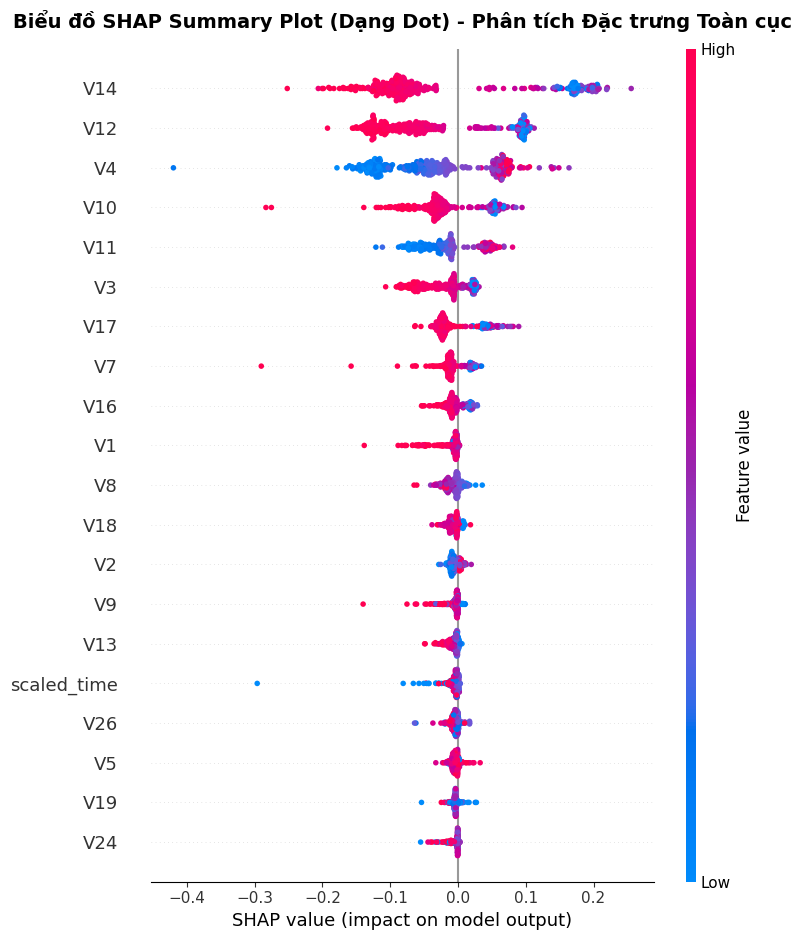

In [6]:
# Vẽ SHAP Summary Plot dạng Dot Plot
# Đồ thị Dot thể hiện hướng tác động (âm hay dương) của biến
plt.figure(figsize=(11, 8))
plt.title("Biểu đồ SHAP Summary Plot (Dạng Dot) - Phân tích Đặc trưng Toàn cục", fontsize=14, fontweight='bold', pad=15)
shap.summary_plot(shap_values, X_sample_shap, plot_type="dot", show=False)
plt.tight_layout()
plt.show()

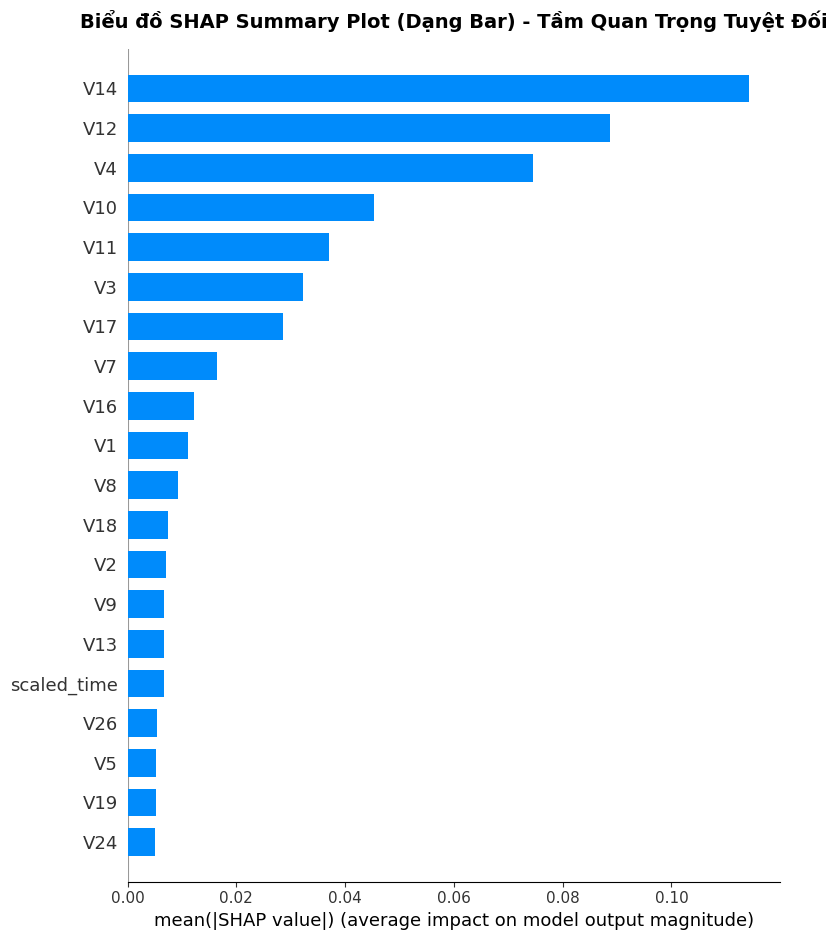

In [7]:
# Vẽ SHAP Summary Plot dạng Bar Plot
# Đồ thị dạng Bar thể hiện giá trị trung bình tuyệt đối của SHAP, phản ánh tầm quan trọng tổng thể
plt.figure(figsize=(11, 8))
plt.title("Biểu đồ SHAP Summary Plot (Dạng Bar) - Tầm Quan Trọng Tuyệt Đối", fontsize=14, fontweight='bold', pad=15)
shap.summary_plot(shap_values, X_sample_shap, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

### Giải Thích Ý Nghĩa Phân Tích SHAP và Cơ Chế Tác Động Của Các Biến Hàng Đầu

#### 1. Nguyên lý cơ bản của SHAP
* SHAP được xây dựng trên lý thuyết **giá trị Shapley** từ Game Theory. Trong đó, mỗi đặc trưng đầu vào đóng vai trò là một "người chơi" tham gia vào một liên minh để sinh ra dự đoán xác suất rủi ro của mô hình.
* Giá trị SHAP của một đặc trưng là đóng góp biên trung bình của nó trên tất cả các tổ hợp đặc trưng có thể có.

#### 2. Phân tích chi tiết các biến chủ đạo: $V_{14}$, $V_{17}$ và $Amount$
* **Đặc trưng $V_{14}$ và $V_{17}$:**
  * Trên biểu đồ **Dot Plot**, ta thấy rõ ràng các chấm màu **Đỏ** (giá trị đặc trưng cao) của $V_{14}$ và $V_{17}$ tập trung bên trái trục trung hòa (SHAP value < 0), tức là chúng kìm hãm xác suất gian lận.
  * Ngược lại, các chấm màu **Xanh** (giá trị đặc trưng thấp) nằm lệch hẳn sang bên phải trục trung hòa (SHAP value > 0). Điều này cho thấy khi giá trị đặc trưng của $V_{14}$ hay $V_{17}$ giảm sâu đột biến, nó là động lực cực kỳ mạnh mẽ thúc đẩy mô hình dự đoán đó là một cuộc giao dịch **Gian lận (Class 1)**.
* **Đặc trưng $Amount$ (Số tiền giao dịch):**
  * $Amount$ có tầm quan trọng thấp hơn các biến PCA cốt lõi toàn cục nhưng lại thể hiện tác động cục bộ rõ rệt ở nhiều điểm giao dịch. Tính chất phi tuyến tính phản ánh qua sự phân bố chấm đỏ ở cả 2 phía.

In [8]:
# Lấy mẫu và thực hiện dự đoán chi tiết cho 1 giao dịch đơn lẻ
# Tìm một giao dịch gian lận thực tế được dự đoán chuẩn xác bởi mô hình
y_pred_sample = model_rf.predict(X_sample_shap)
correct_fraud_indices = X_sample_shap[(y_sample_shap == 1) & (y_pred_sample == 1)].index

if len(correct_fraud_indices) > 0:
    target_idx = correct_fraud_indices[0]
    sample_pos = X_sample_shap.index.get_loc(target_idx)

    sample_transaction = X_sample_shap.iloc[[sample_pos]]
    pred_class = model_rf.predict(sample_transaction)[0]
    pred_proba = model_rf.predict_proba(sample_transaction)[0, 1]

    print(f"DEMO GIAO DỊCH GIAN LẬN ĐƯỢC CHỌN (Index: {target_idx}) ")
    print(f" - Nhãn thực tế (Actual Class): {y_sample_shap.loc[target_idx]} (Fraud)")
    print(f" - Nhãn dự đoán từ mô hình (Predicted Class): {pred_class} (Fraud)")
    print(f" - Xác suất mô hình dự đoán gian lận: {pred_proba*100:.2f}%")
else:
    print("[WARNING] Không tìm thấy mẫu giao dịch phù hợp thỏa mãn yêu cầu.")

DEMO GIAO DỊCH GIAN LẬN ĐƯỢC CHỌN (Index: 49527) 
 - Nhãn thực tế (Actual Class): 1 (Fraud)
 - Nhãn dự đoán từ mô hình (Predicted Class): 1 (Fraud)
 - Xác suất mô hình dự đoán gian lận: 98.00%


[LOG] Đang sinh biểu đồ giải thích cục bộ cho giao dịch tại vị trí mẫu số 10...


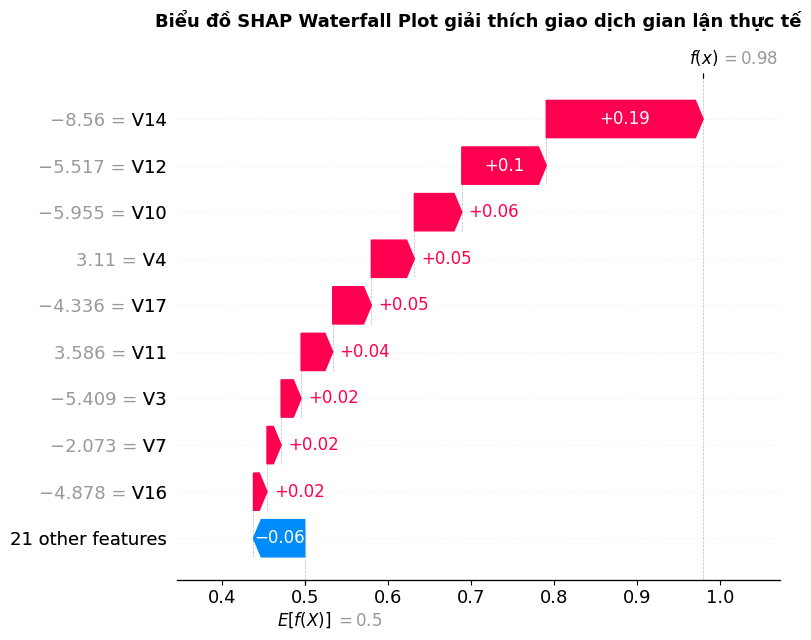


[INFO] Tạo biểu đồ SHAP Force Plot ở dạng đồ thị matplotlib tĩnh:


<Figure size 2000x300 with 0 Axes>

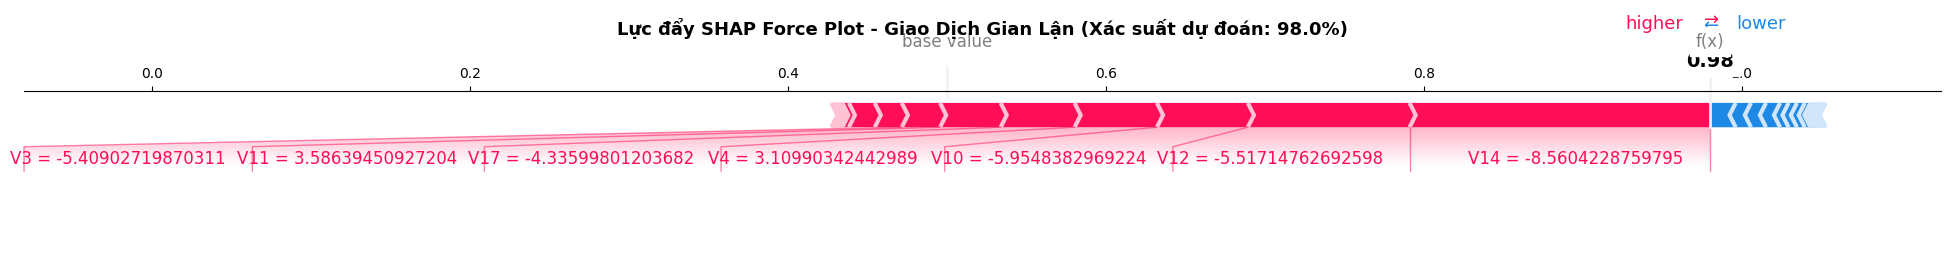

In [9]:
# Trực quan hóa giải thích dự đoán bằng SHAP Force Plot hoặc Waterfall Plot
if len(correct_fraud_indices) > 0:
    print(f"[LOG] Đang sinh biểu đồ giải thích cục bộ cho giao dịch tại vị trí mẫu số {sample_pos}...")

    base_value = explainer.expected_value
    if isinstance(base_value, np.ndarray):
        base_value = base_value[1]
    elif isinstance(base_value, list):
        base_value = base_value[1]

    # Trực quan hóa bằng Waterfall Plot để thể hiện quá trình cộng dồn từ base value tới f(x)
    plt.figure(figsize=(12, 6))
    shap_explanation = shap.Explanation(
        values=shap_values[sample_pos],
        base_values=base_value,
        data=X_sample_shap.iloc[sample_pos],
        feature_names=X_sample_shap.columns
    )

    plt.title(f"Biểu đồ SHAP Waterfall Plot giải thích giao dịch gian lận thực tế", fontsize=13, fontweight='bold', pad=15)
    shap.plots.waterfall(shap_explanation, max_display=10, show=False)
    plt.tight_layout()
    plt.show()

    # Trực quan hóa bằng Force Plot truyền thống (matplotlib tĩnh)
    print("\n[INFO] Tạo biểu đồ SHAP Force Plot ở dạng đồ thị matplotlib tĩnh:")
    plt.figure(figsize=(20, 3))
    shap.force_plot(base_value, shap_values[sample_pos], X_sample_shap.iloc[sample_pos], matplotlib=True, show=False)
    plt.title(f"Lực đẩy SHAP Force Plot - Giao Dịch Gian Lận (Xác suất dự đoán: {pred_proba*100:.1f}%)", fontsize=13, fontweight='bold', pad=40)
    plt.tight_layout()
    plt.show()
else:
    print("[INFO] Không thể hiển thị do thiếu mẫu giao dịch thích hợp.")

## Khám phá Cục bộ (Local Explainability)
Giải thích dự đoán cụ thể cho 1 giao dịch Fraud và 1 giao dịch Non-Fraud bằng Waterfall plot.

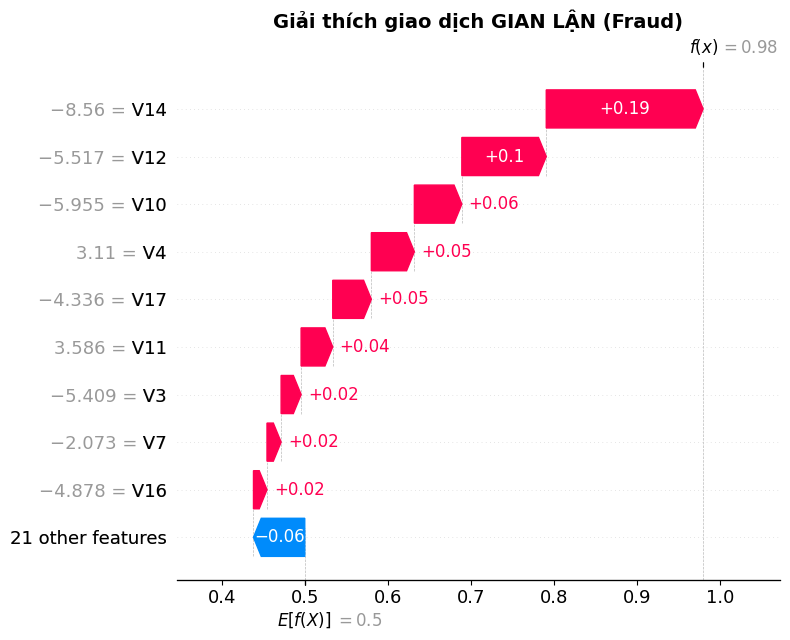

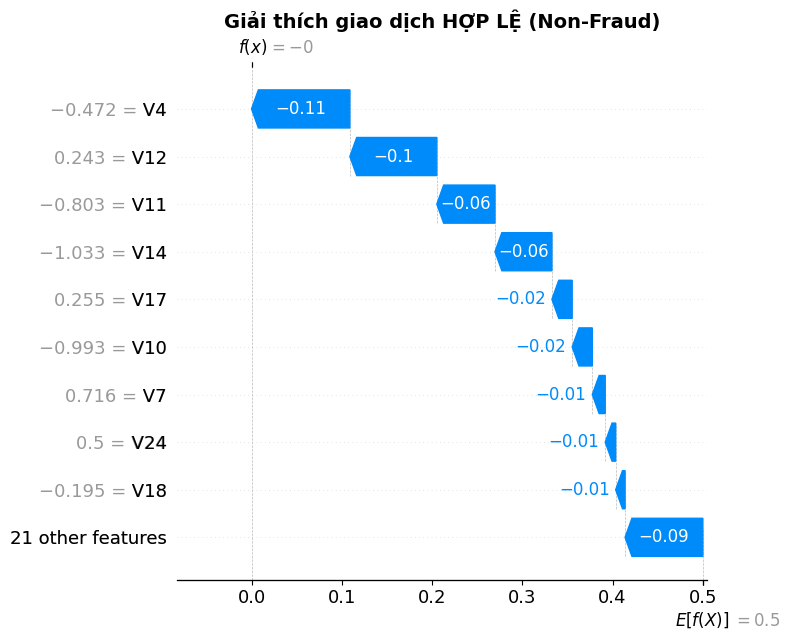

In [10]:
# Giải thích cục bộ giao dịch Fraud và Non-Fraud bằng Waterfall
if 'explainer' in locals() and 'shap_values' in locals():
    fraud_idx = X_sample_shap[y_sample_shap == 1].index
    non_fraud_idx = X_sample_shap[y_sample_shap == 0].index

    def explain_local_waterfall(index, title="SHAP Local Explanation"):
        idx_in_sampled = X_sample_shap.index.get_loc(index)
        expected_value = explainer.expected_value
        if isinstance(expected_value, (list, np.ndarray)):
            expected_value = expected_value[1]

        explanation = shap.Explanation(
            values=shap_values[idx_in_sampled],
            base_values=expected_value,
            data=X_sample_shap.iloc[idx_in_sampled],
            feature_names=X_sample_shap.columns
        )
        plt.figure(figsize=(10, 6))
        plt.title(title, fontsize=14, fontweight='bold')
        shap.plots.waterfall(explanation, max_display=10, show=False)
        plt.tight_layout()
        plt.show()

    if len(fraud_idx) > 0:
        explain_local_waterfall(fraud_idx[0], title="Giải thích giao dịch GIAN LẬN (Fraud)")
    if len(non_fraud_idx) > 0:
        explain_local_waterfall(non_fraud_idx[0], title="Giải thích giao dịch HỢP LỆ (Non-Fraud)")
else:
    print("Chưa chạy các cell thiết lập SHAP bên trên.")

## Trực quan hóa tương tác Đặc trưng (Feature Interaction)
Sự thay đổi của giá trị đặc trưng (ví dụ: `V14`, `V17`) tác động thế nào đến xác suất giao dịch gian lận?

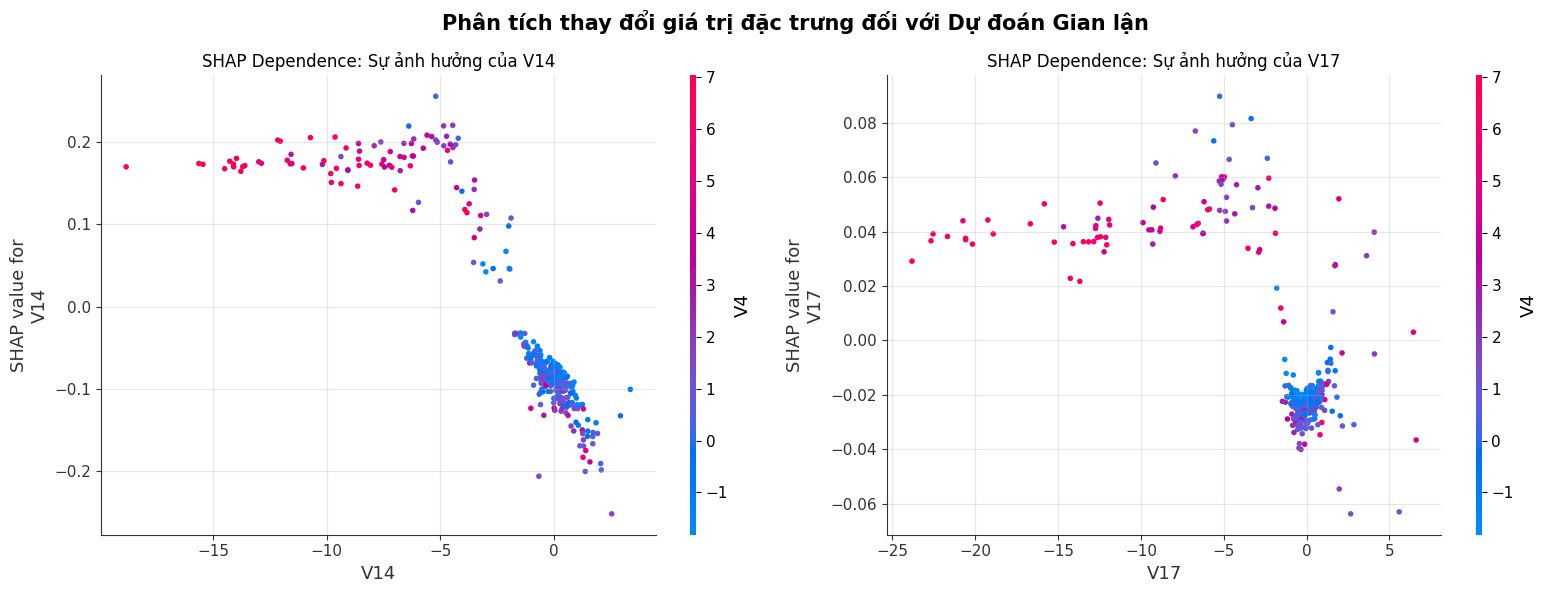

In [15]:
# Trực quan hóa tương tác
if 'shap_values' in locals():
    feat1, feat2 = 'V14', 'V17'

    if feat1 in X_sample_shap.columns and feat2 in X_sample_shap.columns:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Plot 1: SHAP Dependency for V14
        shap.dependence_plot(feat1, shap_values, X_sample_shap, ax=axes[0], show=False)
        axes[0].set_title(f'SHAP Dependence: Sự ảnh hưởng của {feat1}', fontsize=12)
        axes[0].grid(True, alpha=0.3)

        # Plot 2: SHAP Dependency for V17
        shap.dependence_plot(feat2, shap_values, X_sample_shap, ax=axes[1], show=False)
        axes[1].set_title(f'SHAP Dependence: Sự ảnh hưởng của {feat2}', fontsize=12)
        axes[1].grid(True, alpha=0.3)

        plt.suptitle("Phân tích thay đổi giá trị đặc trưng đối với Dự đoán Gian lận", fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Features {feat1}, {feat2} not found in dataset.")
else:
    print("Chưa chạy các cell thiết lập SHAP bên trên.")

### Thay đổi Đặc trưng giao dịch What-If và xem SHAP cập nhật trực tiếp

Chức năng này cho phép tinh chỉnh các biến đầu vào nhạy cảm của giao dịch và quan sát xác suất thay đổi theo thời gian thực.

In [16]:
# Tương tác tinh chỉnh What-If
EDITABLE_FEATURE_MAP_DEMO = {
    "V2": "V2",
    "V5": "V5",
    "V14": "V14",
    "V17": "V17",
    "Amount": "scaled_amount",
}

def explain_modified_transaction_demo(V2=None, V5=None, V14=None, V17=None, Amount=None, transaction_index=0):
    tx = X_sample_shap.iloc[[transaction_index]].copy()
    updates = {"V2": V2, "V5": V5, "V14": V14, "V17": V17, "Amount": Amount}
    for label, value in updates.items():
        feature = EDITABLE_FEATURE_MAP_DEMO.get(label, label)
        if value is not None and feature in tx.columns:
            tx.loc[tx.index[0], feature] = value

    raw_values = explainer.shap_values(tx)
    if isinstance(raw_values, list):
        shap_for_fraud = raw_values[1][0]
    elif len(raw_values.shape) == 3:
        shap_for_fraud = raw_values[0, :, 1]
    else:
        shap_for_fraud = raw_values[0]

    proba = model_rf.predict_proba(tx)[0, 1]
    expected_value_demo = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

    result_df = pd.DataFrame({
        "Feature": X_sample_shap.columns,
        "Value": tx.iloc[0].values,
        "SHAP value": shap_for_fraud,
        "Direction": np.where(shap_for_fraud >= 0, "Tang xac suat Fraud", "Giam xac suat Fraud"),
        "Abs impact": np.abs(shap_for_fraud),
    }).sort_values("Abs impact", ascending=False).head(10).reset_index(drop=True)

    print("[INFO] Modified transaction explanation")
    print(f"[INFO] Fraud probability: {proba:.4%}")
    display(result_df.style.format({"Value": "{:.5f}", "SHAP value": "{:.6f}", "Abs impact": "{:.6f}"}))

    shap.initjs()
    force_plot = shap.force_plot(expected_value_demo, shap_for_fraud, tx.iloc[0],
                                 feature_names=X_sample_shap.columns, matplotlib=False)
    display(force_plot)
    return result_df

base_tx_demo = X_sample_shap.iloc[0]
print("[INFO] Base values for editable features:")
for label, column in EDITABLE_FEATURE_MAP_DEMO.items():
    if column in X_sample_shap.columns:
        print(f"[INFO] {label} ({column}) = {base_tx_demo[column]:.5f}")

try:
    import ipywidgets as widgets
    sliders = {}
    for label, column in EDITABLE_FEATURE_MAP_DEMO.items():
        if column in X_sample_shap.columns:
            center = float(base_tx_demo[column])
            spread = float(max(1.0, X_sample_shap[column].std() * 3))
            sliders[label] = widgets.FloatSlider(
                value=center, min=center - spread, max=center + spread, step=0.05,
                description=label, continuous_update=False, readout_format=".2f",
                style={"description_width": "80px"}, layout=widgets.Layout(width="600px"),
            )
    ui = widgets.VBox(list(sliders.values()))
    out = widgets.interactive_output(explain_modified_transaction_demo, sliders)
    display(ui, out)
    print("[SUCCESS] Interactive SHAP controls are ready.")
except Exception as exc:
    print(f"[INFO] ipywidgets is not available ({exc}). Use function manually:")
    print("[INFO] explain_modified_transaction_demo(V2=0.5, V5=-1.0, V14=-2.0, V17=-1.5, Amount=0.2)")
    explain_modified_transaction_demo(
        V2=float(base_tx_demo.get("V2", 0)),
        V5=float(base_tx_demo.get("V5", 0)),
        V14=float(base_tx_demo.get("V14", 0)),
        V17=float(base_tx_demo.get("V17", 0)),
        Amount=float(base_tx_demo.get("scaled_amount", 0)),
    )

[INFO] Base values for editable features:
[INFO] V2 (V2) = 0.41146
[INFO] V5 (V5) = 1.75635
[INFO] V14 (V14) = -1.03285
[INFO] V17 (V17) = 0.25525
[INFO] Amount (scaled_amount) = -0.34531


Output()

[SUCCESS] Interactive SHAP controls are ready.
